In [55]:
import pandas as pd

from email_outreach.experiment_utils.metric_loader import load_experiment_metrics
from email_outreach.ml.shallow_autoencoder.abstract_contextual_model import AbstractContextualModel
from email_outreach.utils.constants import ROOT_FOLDER
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [56]:
def get_precisions_recalls(path: Path, quantiles=1 - np.linspace(start=0, stop=1, num=100)):
    experiments: list[list] = load_experiment_metrics(path)
    recalls: list[float] = []
    precisions: list[float] = []
    for experiment in experiments:
        recall, precision = AbstractContextualModel.calculate_recall_precision_at_quantiles(experiment,
                                                                                            quantiles=quantiles)[1:3]

        recalls.append(recall)
        precisions.append(precision)

    return recalls, precisions

In [71]:
def get_recalls_auc(path: Path):
    experiments: list[list] = load_experiment_metrics(path)
    recalls_auc: list[float] = []
    for experiment in experiments:
        recall_auc = AbstractContextualModel.calculate_partial_auc(experiment)
        recalls_auc.append(recall_auc)

    return recalls_auc

In [57]:
def delta_pct(lhs: np.ndarray, rhs: np.ndarray, decimals: int = 2 ) -> np.ndarray:
    return ((lhs-rhs)*100).round(decimals)

In [75]:
binary_to_tto_sae_exp: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "btto_sae_exp_v3"
baseline: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "baseline_v2"
baseline_v3: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "baseline_v3"

In [76]:
binary_to_tto_sae_exp_recalls_auc = get_recalls_auc(binary_to_tto_sae_exp)
baseline_recalls_auc = get_recalls_auc(baseline)

In [77]:
np.array(binary_to_tto_sae_exp_recalls_auc).mean(), np.array(baseline_recalls_auc).mean()

(np.float64(0.8661175873236822), np.float64(0.8937074946193079))

In [59]:
binary_to_tto_sae_exp_recalls, binary_to_tto_sae_exp_precisions = get_precisions_recalls(binary_to_tto_sae_exp)
baseline_recalls, baseline_precisions = get_precisions_recalls(baseline)
baseline_v3_recalls, baseline_v3_precisions = get_precisions_recalls(baseline_v3)

In [60]:
print(f"Baseline recall: {np.array(baseline_recalls).mean(axis=0)}")
print(f"Binary to TTO SAE exp recall: {np.array(binary_to_tto_sae_exp_recalls).mean(axis=0)}")
print(f"Baseline v3 recall: {np.array(baseline_v3_recalls).mean(axis=0)}")

Baseline recall: [3.12075052e-05 3.09546501e-02 1.27430414e-01 2.24620259e-01
 3.10711362e-01 3.84651217e-01 4.48944917e-01 5.03436012e-01
 5.53600796e-01 6.06030703e-01 6.57547169e-01 7.03190888e-01
 7.41921737e-01 7.74804656e-01 8.00482675e-01 8.21350049e-01
 8.37900337e-01 8.51987032e-01 8.64264165e-01 8.75441498e-01
 8.85209685e-01 8.93955572e-01 9.02118299e-01 9.09823641e-01
 9.16743273e-01 9.23415361e-01 9.28908504e-01 9.33978552e-01
 9.38015179e-01 9.41959181e-01 9.45461534e-01 9.48885132e-01
 9.51784757e-01 9.54099198e-01 9.56051271e-01 9.58026808e-01
 9.60086029e-01 9.61904085e-01 9.63673826e-01 9.65015782e-01
 9.66433119e-01 9.67556939e-01 9.68657939e-01 9.69598676e-01
 9.70360089e-01 9.71071515e-01 9.71852127e-01 9.72641866e-01
 9.73290874e-01 9.74257364e-01 9.74934795e-01 9.75679848e-01
 9.76271123e-01 9.76934231e-01 9.77525815e-01 9.78155392e-01
 9.78827136e-01 9.79450759e-01 9.79971293e-01 9.80425002e-01
 9.80963221e-01 9.81384816e-01 9.81975128e-01 9.82452377e-01
 9.8304

In [61]:
delta_pct(np.array(binary_to_tto_sae_exp_recalls).mean(axis=0),np.array(baseline_recalls).mean(axis=0))

array([ 2.000e-02,  4.710e+00,  2.060e+00, -1.250e+00, -3.780e+00,
       -5.380e+00, -6.490e+00, -7.050e+00, -7.590e+00, -8.660e+00,
       -9.990e+00, -1.090e+01, -1.141e+01, -1.147e+01, -1.093e+01,
       -1.019e+01, -9.270e+00, -8.240e+00, -7.200e+00, -6.330e+00,
       -5.530e+00, -4.790e+00, -4.220e+00, -3.660e+00, -3.160e+00,
       -2.730e+00, -2.240e+00, -1.870e+00, -1.510e+00, -1.220e+00,
       -9.600e-01, -7.800e-01, -6.300e-01, -4.800e-01, -3.800e-01,
       -3.000e-01, -2.700e-01, -2.700e-01, -2.700e-01, -2.500e-01,
       -2.600e-01, -2.600e-01, -2.500e-01, -2.300e-01, -2.100e-01,
       -1.900e-01, -1.700e-01, -1.700e-01, -1.500e-01, -1.700e-01,
       -1.600e-01, -1.700e-01, -1.500e-01, -1.400e-01, -1.300e-01,
       -1.200e-01, -1.200e-01, -1.300e-01, -1.200e-01, -1.000e-01,
       -9.000e-02, -8.000e-02, -7.000e-02, -5.000e-02, -5.000e-02,
       -5.000e-02, -3.000e-02, -4.000e-02, -5.000e-02, -6.000e-02,
       -6.000e-02, -5.000e-02, -4.000e-02, -4.000e-02, -2.000e

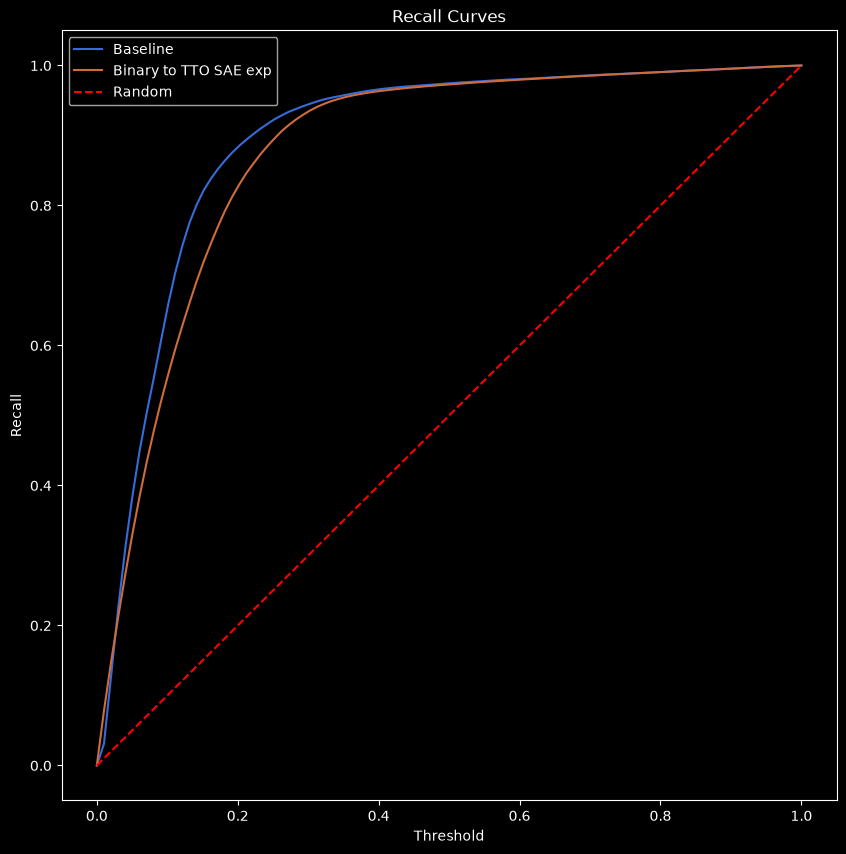

In [62]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

# plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_v3_recalls).mean(axis=0), label="Baselinev3")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(binary_to_tto_sae_exp_recalls).mean(axis=0),
         label="Binary to TTO SAE exp")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")
plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

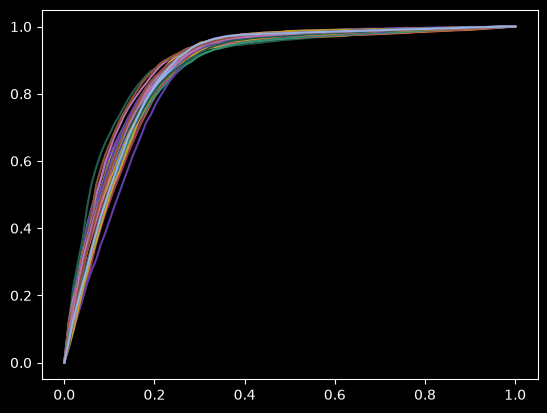

In [63]:
for i in range(len(binary_to_tto_sae_exp_recalls)):
    plt.plot(np.linspace(start=0, stop=1, num=100), np.array(binary_to_tto_sae_exp_recalls)[i],
         label="Binary to TTO SAE exp")

In [64]:
sae_experiments: list[list] = load_experiment_metrics(binary_to_tto_sae_exp)

In [65]:
sae_s = []

for experiment in sae_experiments:
    sae_s += [metric.prediction for metric in experiment]

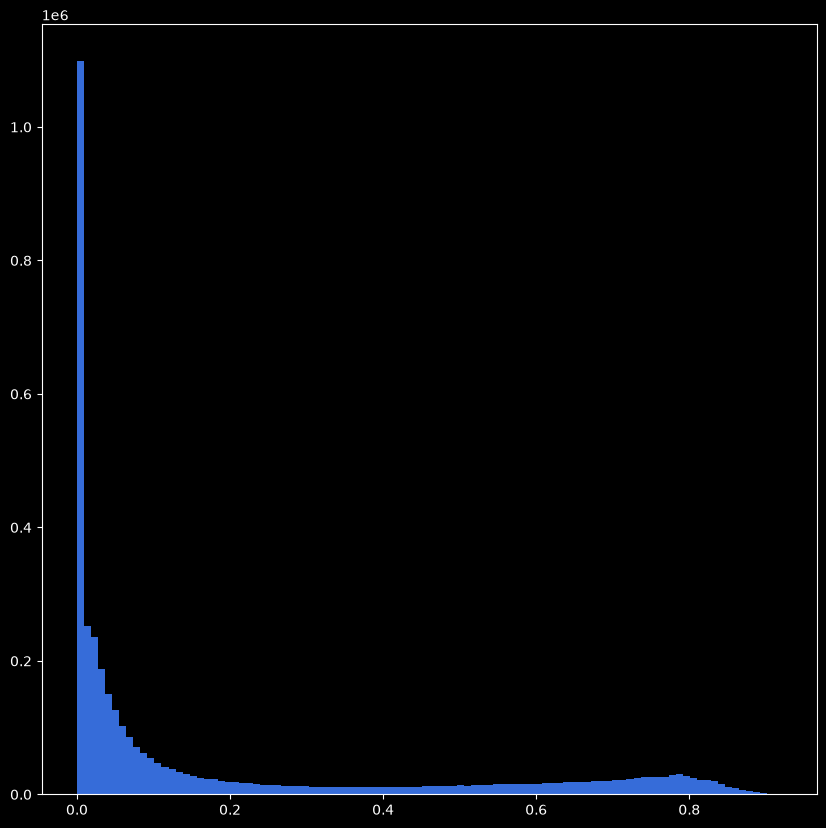

In [66]:
plt.figure(figsize=(10, 10))

plt.hist(sae_s, bins=100)
plt.show()

In [67]:
base_experiments: list[list] = load_experiment_metrics(baseline)

In [68]:
base_s = []

for experiment in base_experiments:
    base_s += [metric.prediction for metric in experiment]

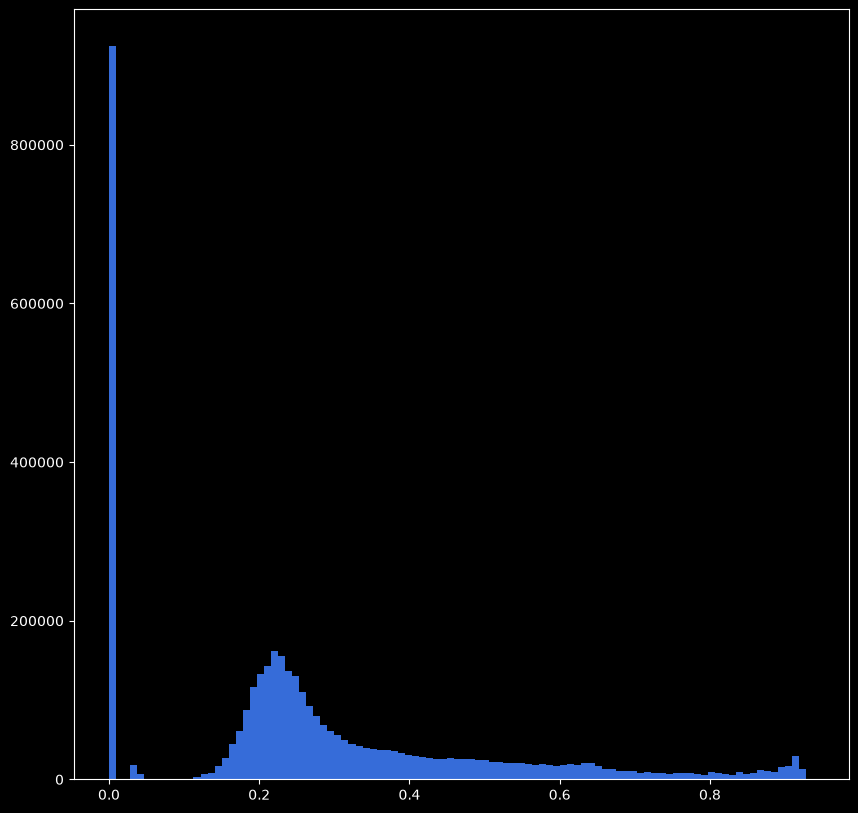

In [69]:
plt.figure(figsize=(10, 10))

plt.hist(base_s, bins=100)
plt.show()

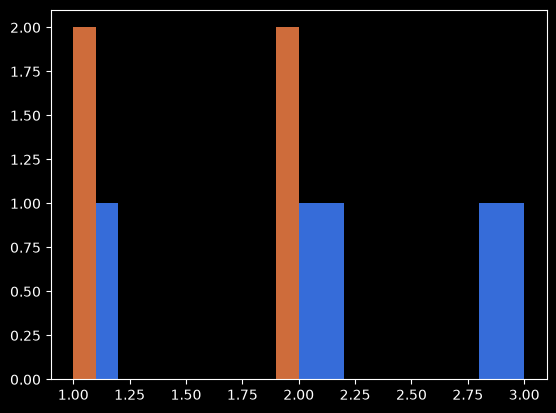

In [70]:
plt.hist([1,2,3])
plt.hist([1,1,2,2])
plt.show()